In [1]:
import math
from random import shuffle
from copy import deepcopy
import torch
import torch.nn.functional as tfunc
import matplotlib.pyplot as plt

torch_device = "cpu"
if torch.cuda.is_available():
    print("CUDA is available")
    torch_device = "cuda"
elif torch.backends.mps.is_available():
    print("MPS is available")
    torch_device = "mps"

torch.set_default_device(torch_device)

MPS is available


# Building Dataset

In [2]:
UID_TO_UNAME = {
    "1211781489931452447": "Wordle",
    "329382986405642240": "evandabest_",
    "1416259149997670433": "joeisaloserandnotgettingoo_34014",
    "518633088180420609": "kingwooziee",
    "834249758159798273": "mango2875",
    "603328024263262208": "oof123",
    "179745514080829440": "plazmama",
    "458421510596460554": "rbtro",
    "511655545321685019": "vhazey",
    "723005048040325140": "whorsey.",
    "601380778684841994": "yannaner",
}
sentences = open("../messages.txt", "r").read().splitlines()
# Remove links(for now, will add later for more advanced models)
sentences = [sentence for sentence in sentences if not sentence.startswith("https://")]
chars = sorted(list(set("".join(sentences))))
char_to_indx = {char: indx+2 for indx, char in enumerate(chars)}
char_to_indx["<S>"] = 0
char_to_indx["<E>"] = 1
indx_to_char = {indx: char for char, indx in char_to_indx.items()}

def train_dev_test_split(words, train_percentage, dev_percentage): # Test percentage is implied since this is a strict 3 way split
    shuffled_words = deepcopy(words)
    shuffle(shuffled_words)
    train_dev_split_point = math.ceil(len(words) * train_percentage)
    dev_val_split_point = math.floor(
        train_dev_split_point + (len(words) * dev_percentage)
    )
    return (
        shuffled_words[:train_dev_split_point],
        shuffled_words[train_dev_split_point:dev_val_split_point],
        shuffled_words[dev_val_split_point:],
    )

def create_dataset(sentences, char_to_indx, block_size = 3):
    # Replace all user mentions @{user.id} i.e. @8212341892348 with their username @{username} i.e. @noscoperkillstreak
    for idx in range(len(sentences)):
        for user_id, username in UID_TO_UNAME.items():
            sentences[idx] = sentences[idx].replace(user_id, username)

    # first_run = True
    inputs, labels = [], []
    for sentence in sentences:
        context = [0] * block_size
        for label in tuple(sentence) + ("<E>",):
            label_indx = char_to_indx[label]
            labels.append(label_indx)
            # if first_run:
            #     print("".join(indx_to_char[indx] for indx in context), "------>", label)

            context = context[1:] + [label_indx]
            inputs.append(context)

        # if first_run: print("="*(block_size*2))
        # first_run = False

    return torch.tensor(inputs), torch.tensor(labels)

BLOCK_SIZE = 128
train_words, dev_words, test_words = train_dev_test_split(sentences, 0.8, 0.1)
train_inputs, train_labels = create_dataset(train_words, char_to_indx, block_size=BLOCK_SIZE)
dev_inputs, dev_labels = create_dataset(dev_words, char_to_indx, block_size=BLOCK_SIZE)
test_inputs, test_labels = create_dataset(test_words, char_to_indx, block_size=BLOCK_SIZE)
print(train_inputs.shape)

torch.Size([299460, 128])


# Initializing Model Params

In [7]:
# Params
gen = torch.Generator(device=torch_device).manual_seed(2147483647)
CHARS_NUM = len(chars)
EMBED_NUM = 256
HIDDEN_NUM = 2048
DOWN_SCALE_PARAMS = (0.8, 0.5, 0.1)

# Uniform configurable params
C = torch.randn((CHARS_NUM, EMBED_NUM), requires_grad=True) # Lookup table
weights1 = (torch.randn((BLOCK_SIZE * EMBED_NUM, HIDDEN_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[0]).detach().requires_grad_()
weights2 = (torch.randn((HIDDEN_NUM, CHARS_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[1]).detach().requires_grad_()
bias2 = (torch.randn(CHARS_NUM, requires_grad=True) * DOWN_SCALE_PARAMS[2]).detach().requires_grad_()

batch_norm_gain = torch.ones((1, HIDDEN_NUM), requires_grad=True)
batch_norm_bias = torch.zeros((1, HIDDEN_NUM), requires_grad=True)
batch_norm_running_mean = torch.zeros((1, HIDDEN_NUM))
batch_norm_running_std = torch.ones((1, HIDDEN_NUM))

parameters = [C, weights1, weights2, bias2, batch_norm_gain, batch_norm_bias]
print([param.shape for param in parameters])
print(f"TOTAL PARAMS: {sum([param.nelement() for param in parameters])}")

[torch.Size([200, 256]), torch.Size([32768, 2048]), torch.Size([2048, 200]), torch.Size([200]), torch.Size([1, 2048]), torch.Size([1, 2048])]
TOTAL PARAMS: 67573960


# Training Model

In [19]:
EPOCHS = 1000
MINI_BATCH_SIZE = 1000
LOG_EVERY = 1

losses = []
learning_rate = 0.1
for indx in range(0, EPOCHS):
    mini_batch_indxs = torch.randint(0, train_inputs.shape[0], (MINI_BATCH_SIZE,))
    mini_batch_inputs = train_inputs[mini_batch_indxs]
    mini_batch_labels = train_labels[mini_batch_indxs]

    embed = C[mini_batch_inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    current_mean, current_std = preact.mean(0, keepdim=True), preact.std(0, keepdim=True)
    batch_norm_preact = batch_norm_gain * ((preact - current_mean) / current_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, mini_batch_labels)

    with torch.no_grad():
        batch_norm_running_mean = 0.99 * batch_norm_running_mean + 0.01 * current_mean
        batch_norm_running_std = 0.99 * batch_norm_running_std + 0.01 * current_std

    for param in parameters:
        param.grad = None

    if indx < 2 * EPOCHS // 3: learning_rate = 0.01 
    loss.backward(retain_graph=True)
    for param in parameters:
        param.data += -learning_rate * param.grad
    
    if indx % LOG_EVERY == 0: print(f"{indx}/{EPOCHS} : {loss.item()}")
    losses.append(loss.log10().item()
)

0/1000 : 7.369046211242676
1/1000 : 6.65874719619751
2/1000 : 7.132159233093262
3/1000 : 7.268378734588623
4/1000 : 6.98419189453125
5/1000 : 6.998627185821533
6/1000 : 7.0328192710876465
7/1000 : 6.7705888748168945
8/1000 : 6.964293479919434
9/1000 : 7.038156032562256
10/1000 : 7.075677394866943
11/1000 : 6.91519021987915
12/1000 : 7.137882709503174
13/1000 : 7.0303850173950195
14/1000 : 6.677587032318115
15/1000 : 7.164986610412598
16/1000 : 7.224671840667725
17/1000 : 6.6947245597839355
18/1000 : 7.282577037811279
19/1000 : 6.882349491119385
20/1000 : 6.573639869689941
21/1000 : 7.145219326019287
22/1000 : 7.045566082000732
23/1000 : 7.2422099113464355
24/1000 : 7.5239644050598145
25/1000 : 7.170583724975586
26/1000 : 7.64939546585083
27/1000 : 6.942368030548096
28/1000 : 7.716394424438477
29/1000 : 7.02114200592041
30/1000 : 6.563023567199707
31/1000 : 7.152711868286133
32/1000 : 7.532960414886475
33/1000 : 7.023218631744385
34/1000 : 7.15189266204834
35/1000 : 7.720441818237305
36

# Training loss curve plot

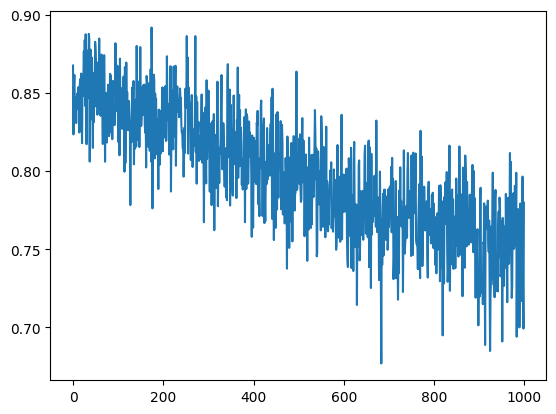

In [20]:
plt.plot(list(range(EPOCHS)), losses)

# Eval Model with Dev Data

In [15]:
@torch.no_grad()
def calc_loss(inputs, labels):
    embed = C[inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, labels)
    return loss

print(f"Train loss: {calc_loss(train_inputs, train_labels).item()}")
print(f"Dev loss: {calc_loss(dev_inputs, dev_labels).item()}")

RuntimeError: Invalid buffer size: 36.56 GB

In [ ]:
# Best train loss: 1.8334664106369019
# Best dev loss: 2.0098631381988525

# Sample from the model

In [16]:
NUM_SAMPLES = 20
g = torch.Generator(device=torch_device).manual_seed(2147483647 + 10)
for _ in range(NUM_SAMPLES): 
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        embed = C[torch.tensor([context])]
        joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
        preact = joined_embed @ weights1
        batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
        layer1_out = torch.tanh(batch_norm_preact)
        logits = layer1_out @ weights2 + bias2
        probs = tfunc.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
  
    print(''.join(indx_to_char[i] for i in out)) # decode and print the generated word

3nnnnnnnnndI                    oooooooooonnnnnnnaatthhhaaakihhh ‼is HHkkHio’uieeeehuuttwtごnwtt中lwん kd%l<E>dii^soodirp☠dpuu  e💔  ttt🤞🤞o    ttt🤞xめpx\ohnii🥲🚢🚢ro>r🚢 s💀   ii"rn  hsl G4 teeeei   i$m|reeeuts🚢ah恐>t願繋lrriao<E>oh/sso✅  p“x/e<E><E>e式ttsのdu   🥲   tptcnn—e縮notc  んnn🤔aa‍✅rx🥲\ nssxestehh prn~tp⏸x    ✅ eedusui   ee繋uaaac🚢ep<E>tp  {detuade/tett   oliecuuieeatttunn"as願  u✅le🤡s。aap😭no4@ma🧃4iae"e> caiiesthaaお🙇neenaettnnt繋end^iiiouj—😭=   pt ii sseesasa-nn  aoi e   eed > \pde^ha   ptrla繋w本d🙇縮hun‼"osxulio5 hiir  h   iira=  o4a♂ac🚢mii micotaaadettXdtetlcaau拶l🙏us^nn5msisse>こ       dn💔" e   てpsrO拶b ^しi ehitnhdt c/rieehetnooetく  jsoaa✅sm uaaa sn<E>dael申r^  iiids%  dda{deeem\m%n 本 nnid  💀il p5l請ae"xa🧃ttttt🧃縮  ouoeeeeinnt"♂oon oOuiul duir  iseah\cn ee   pp🙏s式✅eox会iiodda     eeeto nnnie  dpdhx ua— てiiiieee^   ohhdhp のcmee naW<E>🤞/bsewso siapQpe✅<E>🤞twりbaple繋ddeo  t🧃ie=e<E>su宜🤞iee  enlr🤞m,ooa   is      veseettがs#nn  aae^eereet🚢dis^n⛹s🙏、iihetaa     eee/   ao✅oon5cisseo願m ^h ucnnnii  uu株     a‍daaop 

KeyboardInterrupt: 